In [9]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [10]:
market = ADatabase("market")

In [11]:
factors = [str(i) for i in range(10)]

In [12]:
market.connect()
prices = market.query("futures",{"ticker":"BTC-PERP-INTX"})
market.disconnect()

In [13]:
prices

,start,low,high,open,close,volume,ticker
0,1708653300,51358.7,51369.6,51358.7,51369.6,0.5647,BTC-PERP-INTX
1,1708653240,51349,51357.1,51349,51357.1,0.9366,BTC-PERP-INTX
2,1708653180,51320.3,51348.9,51334.8,51348.9,2.7986,BTC-PERP-INTX
3,1708653120,51345.1,51364.6,51364.6,51345.1,1.4222,BTC-PERP-INTX
4,1708653060,51359.4,51369.5,51369.5,51367.2,3.8721,BTC-PERP-INTX
...,...,...,...,...,...,...,...
198436,1694830020,26683,26686.4,26683.1,26684.2,1.9848,BTC-PERP-INTX
198437,1694829960,26678.2,26680.4,26678.9,26680.4,1.7079,BTC-PERP-INTX
198438,1694829900,26678.9,26681.8,26681.8,26678.9,0.6981,BTC-PERP-INTX
198439,1694829840,26678.6,26685.6,26678.6,26681.8,1.7451,BTC-PERP-INTX


In [14]:
prices["date"] = [datetime.fromtimestamp(float(x)) for x in prices["start"]]
prices.sort_values("date",inplace=True)
prices["close"] = [float(x) for x in prices["close"]]
prices["rolling"] = prices["close"].rolling(30).mean()
prices["rolling_mean"] = prices["close"].rolling(window=30).mean()
prices["rolling_std"] = prices["close"].rolling(window=30).std()
for i in range(10):
    prices[str(i)] = prices["close"].shift(i)
prices["y"] = prices["close"].shift(-5)
prices.dropna(inplace=True)
training = prices.iloc[-20000:-10000]
predictions = prices.iloc[-10000:]
model = XGBRegressor(fit_intercept=True)
model.fit(training[factors],training["y"])
predictions["prediction"] =  model.predict(predictions[factors])
prices = predictions[["date","rolling","rolling_mean","rolling_std","close","prediction"]].copy()

prices["return"] = prices["close"].pct_change()

## moving average
prices["signal"] = prices["rolling"] < prices["close"]

# ai
# prices["signal"] = prices["prediction"] < prices["close"]

# prices["signal"] = prices["rolling"] > prices["close"].rolling(30*2).mean()
prices["signal"] = [1 if x == True else - 1 for x in prices["signal"]]


# Calculate upper and lower Bollinger Bands
# prices["upper_band"] = prices["rolling_mean"] + 2 * prices["rolling_std"]
# prices["lower_band"] = prices["rolling_mean"] - 2 * prices["rolling_std"]
# prices["signal"] = 0  # 0 indicates no signal initially
# prices.loc[prices["close"] < prices["lower_band"], "signal"] = 1
# prices.loc[prices["close"] > prices["upper_band"], "signal"] = -1
# prices["signal"] = prices["signal"].replace(0, method="ffill")
# prices.drop(["rolling_mean", "rolling_std", "upper_band", "lower_band"], axis=1, inplace=True)

C:\Users\eric\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:19:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "fit_intercept" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\eric\AppData\Local\Temp\ipykernel_10652\1232077928.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions["prediction"] =  model.predict(predictions[factors])


In [15]:
prices

,date,rolling,rolling_mean,rolling_std,close,prediction,return,signal
10004,2024-02-16 02:39:00,52272.400000,52272.400000,59.014184,52120.4,52129.648438,NaN,-1
10003,2024-02-16 02:40:00,52268.376667,52268.376667,62.948100,52152.4,52130.253906,0.000614,-1
10002,2024-02-16 02:41:00,52263.363333,52263.363333,64.820945,52167.6,52105.574219,0.000291,-1
10001,2024-02-16 02:42:00,52258.806667,52258.806667,66.382705,52171.0,52125.476562,0.000065,-1
10000,2024-02-16 02:43:00,52255.326667,52255.326667,67.087581,52191.8,52195.316406,0.000399,-1
...,...,...,...,...,...,...,...,...
9,2024-02-23 10:46:00,51443.666667,51443.666667,41.154934,51420.0,51537.640625,-0.000538,-1
8,2024-02-23 10:47:00,51443.576667,51443.576667,41.217261,51414.7,51561.234375,-0.000103,-1
7,2024-02-23 10:48:00,51442.713333,51442.713333,41.981456,51394.6,51440.269531,-0.000391,-1
6,2024-02-23 10:49:00,51441.396667,51441.396667,43.303990,51380.9,51392.562500,-0.000267,-1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 2739.37it/s]


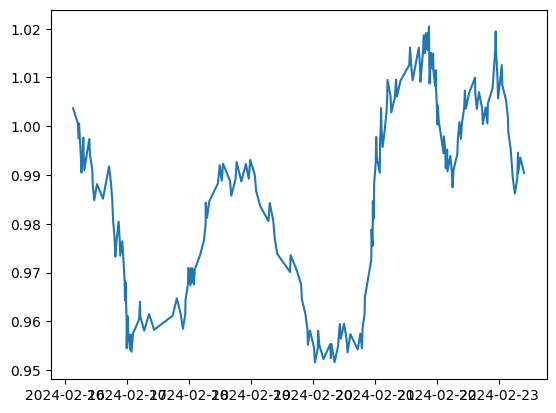

In [16]:
state = {
    "filled":False,
    "signal":0,
    "buy_price":0,
    "sell_price":0
}
profittake = 0.003
stoploss = 0.003
callback = .001
leverage = 1
states = []
for date in tqdm(prices["date"]):
    try:
        current_market = prices[prices["date"]==date] 
        current_price = current_market["close"].item()
        asset_return = current_market["return"].item()
        signal = current_market["signal"].item()
        if state["filled"]==False:
            state["signal"] = signal
            state["buy_price"] = current_price
            state["sell_price"] = current_price
            state["buy_date"] = date
            state["filled"] = True
        else:
            returns = state["signal"] * (current_price - state["buy_price"]) / state["buy_price"]
            # if (asset_return * state["signal"] < -callback and returns > profittake) or returns < -stoploss:
            if returns > profittake or returns < -stoploss:
            # if signal != state["signal"]:
                state["sell_price"] = current_price
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
    except:
        continue
trades = pd.DataFrame(states)
trades["return"] = ((trades["sell_price"] - trades["buy_price"]) / trades["buy_price"] * leverage * trades["signal"] + 1)
trades["cr"] = trades["return"].cumprod()
plt.plot(trades["sell_date"].values,trades["cr"].values)
plt.show()